# 04 · Recomendaciones Tácticas y Visualización Final

Este notebook cierra el proyecto: convierte el EDA, el análisis espacial 360 y el modelo de OBV en recomendaciones tácticas accionables.

La lógica es deliberadamente simple: no prometemos que un modelo prediga cada córner con precisión. Usamos evidencia agregada para decidir qué patrones conviene entrenar, mantener o reducir.


## 1 · Setup y carga de datos


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch
import plotly.express as px

pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid', palette='husl')

_here = Path().resolve()
_root = _here.parent if _here.name == 'notebooks' else _here
PROCESSED_DIR = _root / 'data' / 'processed'
FIGURES_DIR = _root / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

TYPES = ['Inswinging', 'Outswinging', 'Short', 'Straight']
COLORS_TYPE = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
COLOR_BY_TYPE = dict(zip(TYPES, COLORS_TYPE))
BG = '#0d1b2a'

corner_features = pd.read_parquet(PROCESSED_DIR / 'corner_features.parquet')
from_corner_enr = pd.read_parquet(PROCESSED_DIR / 'from_corner_enriched.parquet')
shots_fc = pd.read_parquet(PROCESSED_DIR / 'shots_from_corner.parquet')
shots_sp = pd.read_parquet(PROCESSED_DIR / 'shots_second_phase.parquet')

print(f'corner_features: {corner_features.shape[0]:,} filas x {corner_features.shape[1]} cols')
print(f'from_corner_enriched: {from_corner_enr.shape[0]:,} filas x {from_corner_enr.shape[1]} cols')
print(f'shots_from_corner: {shots_fc.shape[0]:,} filas')
print(f'shots_second_phase: {shots_sp.shape[0]:,} filas')


corner_features: 13,279 filas x 60 cols
from_corner_enriched: 124,740 filas x 153 cols
shots_from_corner: 5,607 filas
shots_second_phase: 110 filas


### 1.1 · Métricas tácticas derivadas

Creamos las mismas variables usadas en el cierre del notebook 3. La idea es que cada fila siga siendo un córner, pero con métricas fáciles de leer para un staff: xG por córner, OBV del envío, retención, contraataque y zona de destino.


In [2]:
def add_recommendation_features(df):
    """Agrega features tácticas legibles sin cambiar el grano: una fila = un córner."""
    out = df.copy()
    out['match_date'] = pd.to_datetime(out['match_date'])
    out['xg_per_corner'] = out['seq_sum_xg'].fillna(0)
    out['retained'] = out['sequence_outcome'].eq('retained')
    out['shot'] = out['generated_shot'].astype(int)

    x, y = out['end_x'], out['end_y']
    out['end_zone'] = np.select(
        [
            (x >= 114) & y.between(34, 46),
            (x >= 108) & y.between(24, 56),
            (x >= 102) & y.between(18, 62),
            x >= 96,
        ],
        ['six_yard', 'central_box', 'wide_box', 'edge_or_short'],
        default='recycled',
    )
    out['distance_to_goal_center'] = np.hypot(120 - x, 40 - y)
    out['low_value_zone'] = out['end_zone'].isin(['edge_or_short', 'recycled'])
    return out

def summarize(grouped):
    """Resumen estándar usado en todo el notebook."""
    return grouped.agg(
        n=('id', 'count'),
        obv_mean=('obv_total_net', 'mean'),
        xg_per_100=('xg_per_corner', lambda s: 100 * s.mean()),
        shot_rate=('shot', 'mean'),
        counter_per_100=('led_to_counter', lambda s: 100 * s.mean()),
        retained_rate=('retained', 'mean'),
    )

corners = add_recommendation_features(corner_features).dropna(subset=['obv_total_net']).copy()

league_summary = pd.DataFrame({
    'metric': ['corners', 'shot_rate', 'xg_per_100', 'obv_mean', 'counter_per_100', 'retained_rate'],
    'value': [
        len(corners),
        corners['shot'].mean(),
        100 * corners['xg_per_corner'].mean(),
        corners['obv_total_net'].mean(),
        100 * corners['led_to_counter'].mean(),
        corners['retained'].mean(),
    ],
})
display(league_summary.round(4))


,metric,value
0,corners,13020.0000
1,shot_rate,0.3860
2,xg_per_100,3.6405
3,obv_mean,0.0088
4,counter_per_100,0.8372
5,retained_rate,0.2329


## 2 · Scorecard global: qué patrones sostienen la recomendación

El scorecard usa datos reales, no sólo el modelo. Un patrón recomendable debe combinar volumen suficiente, buen OBV/xG y riesgo de contraataque controlado.


In [3]:
type_scorecard = (
    summarize(corners.groupby('corner_type', observed=True))
    .reindex(TYPES)
    .reset_index()
)

type_zone_scorecard = (
    summarize(corners.groupby(['corner_type', 'end_zone'], observed=True))
    .reset_index()
    .query('n >= 150')
    .sort_values(['obv_mean', 'xg_per_100'], ascending=False)
)

display(type_scorecard.round(4))
display(type_zone_scorecard.head(12).round(4))


,corner_type,n,obv_mean,xg_per_100,shot_rate,counter_per_100,retained_rate
0,Inswinging,4475,0.0151,3.8294,0.3497,0.7151,0.2460
1,Outswinging,5463,0.0121,3.8484,0.4342,0.9519,0.2107
2,Short,2636,-0.0091,2.9759,0.3414,0.8346,0.2606
3,Straight,446,0.0115,3.1279,0.4238,0.6726,0.2108


,corner_type,end_zone,n,obv_mean,xg_per_100,shot_rate,counter_per_100,retained_rate
0,Inswinging,central_box,2870,0.0177,4.0380,0.4024,0.8362,0.2530
13,Straight,central_box,214,0.0175,3.6278,0.4439,0.0000,0.2383
2,Inswinging,six_yard,1353,0.0151,3.9132,0.2727,0.5174,0.2572
12,Short,wide_box,156,0.0149,2.9529,0.3910,0.0000,0.2885
4,Outswinging,central_box,4146,0.0145,4.1222,0.4583,0.9648,0.2123
8,Outswinging,wide_box,638,0.0130,3.3926,0.4922,0.4702,0.1818
7,Outswinging,six_yard,446,0.0048,3.3256,0.2668,0.8969,0.2578
10,Short,edge_or_short,2254,-0.0116,2.9249,0.3341,0.9317,0.2635
11,Short,recycled,160,-0.0132,3.9119,0.4125,0.6250,0.2250
1,Inswinging,edge_or_short,160,-0.0223,0.7662,0.0688,0.6250,0.1062


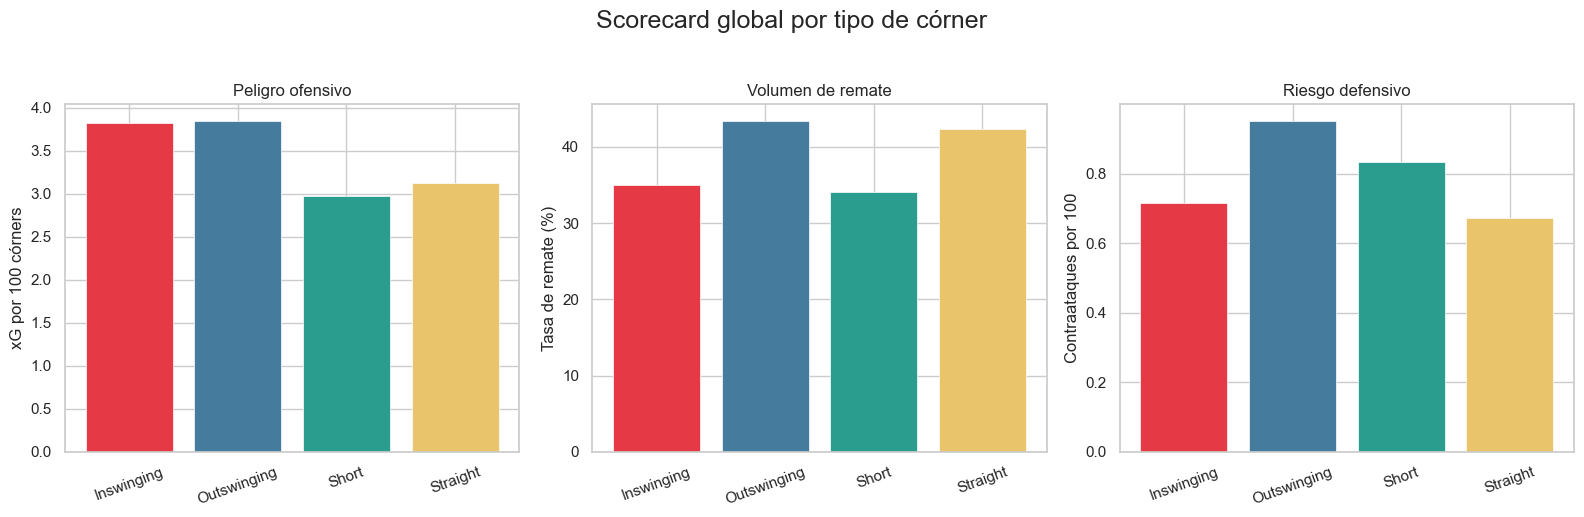

In [4]:
# Visualización compacta: valor ofensivo y riesgo por tipo.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_df = type_scorecard.copy()
colors = plot_df['corner_type'].map(COLOR_BY_TYPE)

axes[0].bar(plot_df['corner_type'], plot_df['xg_per_100'], color=colors, edgecolor='white', lw=0.5)
axes[0].set_title('Peligro ofensivo')
axes[0].set_ylabel('xG por 100 córners')

axes[1].bar(plot_df['corner_type'], plot_df['shot_rate'] * 100, color=colors, edgecolor='white', lw=0.5)
axes[1].set_title('Volumen de remate')
axes[1].set_ylabel('Tasa de remate (%)')

axes[2].bar(plot_df['corner_type'], plot_df['counter_per_100'], color=colors, edgecolor='white', lw=0.5)
axes[2].set_title('Riesgo defensivo')
axes[2].set_ylabel('Contraataques por 100')

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Scorecard global por tipo de córner', fontsize=18, y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'recommendations_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 · Simulación conservadora: mover 20% de envíos de bajo valor

No simulamos “reemplazar Outswinging por Short” porque los datos no sostienen eso como recomendación general. La simulación es más accionable: **si un equipo mueve 20% de sus envíos a zonas de bajo valor (`edge_or_short`, `recycled`) hacia el benchmark de envíos a `central_box`, cuánto podría mejorar?**

Es una estimación de entrenamiento, no una promesa causal. Sirve para ordenar equipos donde el ajuste puede valer más.


In [5]:
central_df = corners[corners['end_zone'].eq('central_box')]
central_benchmark = {
    'obv': central_df['obv_total_net'].mean(),
    'xg': central_df['xg_per_corner'].mean(),
    'shot': central_df['shot'].mean(),
    'counter': central_df['led_to_counter'].mean(),
}

simulation_rows = []
for team, team_df in corners.groupby('team', observed=True):
    low = team_df[team_df['low_value_zone']]
    shift_n = int(np.floor(0.20 * len(low)))
    if shift_n == 0:
        continue

    # Comparamos el promedio actual del equipo en zonas bajas contra el benchmark liga en central_box.
    # Esto evita asumir que todos los equipos tienen el mismo punto de partida.
    current_low = {
        'obv': low['obv_total_net'].mean(),
        'xg': low['xg_per_corner'].mean(),
        'shot': low['shot'].mean(),
        'counter': low['led_to_counter'].mean(),
    }

    simulation_rows.append({
        'team': team,
        'n_corners': len(team_df),
        'low_zone_corners': len(low),
        'shift_20pct': shift_n,
        'delta_obv': shift_n * (central_benchmark['obv'] - current_low['obv']),
        'delta_xg': shift_n * (central_benchmark['xg'] - current_low['xg']),
        'delta_shots': shift_n * (central_benchmark['shot'] - current_low['shot']),
        'delta_counters': shift_n * (central_benchmark['counter'] - current_low['counter']),
    })

simulation = (
    pd.DataFrame(simulation_rows)
    .sort_values(['delta_xg', 'delta_obv'], ascending=False)
    .reset_index(drop=True)
)

display(simulation.head(12).round(3))


,team,n_corners,low_zone_corners,shift_20pct,delta_obv,delta_xg,delta_shots,delta_counters
0,Pachuca,900,332,66,1.931,1.164,8.598,0.380
1,Tijuana,653,190,38,1.089,0.891,7.310,-0.667
2,Monterrey,800,159,31,0.891,0.682,3.916,-0.118
3,Atlético San Luis,641,147,29,0.826,0.615,4.709,0.057
4,Necaxa,618,127,25,0.729,0.573,3.972,0.022
5,Guadalajara,753,164,32,0.937,0.517,5.318,-0.305
6,Cruz Azul,811,165,33,0.915,0.415,3.738,0.289
7,Toluca,719,146,29,0.809,0.389,3.264,-0.143
8,Mazatlán,570,120,24,0.673,0.383,0.428,0.211
9,Pumas UNAM,742,125,25,0.716,0.383,3.462,0.219


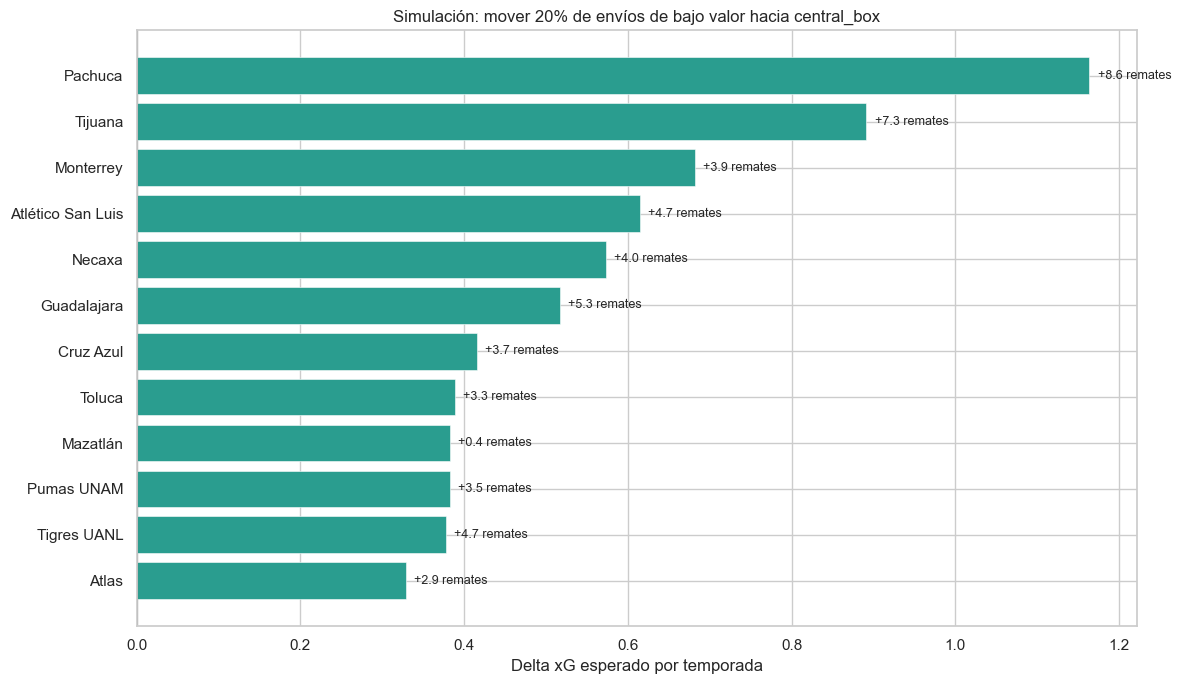

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
plot_sim = simulation.head(12).sort_values('delta_xg')
ax.barh(plot_sim['team'], plot_sim['delta_xg'], color='#2a9d8f', edgecolor='white', lw=0.4)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Delta xG esperado por temporada')
ax.set_title('Simulación: mover 20% de envíos de bajo valor hacia central_box')
for _, row in plot_sim.iterrows():
    ax.text(row['delta_xg'] + 0.01, row['team'], f'+{row["delta_shots"]:.1f} remates', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'recommendations_simulation.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 · Recomendación por equipo

La tabla no intenta dictar una jugada única. Clasifica el foco de entrenamiento más lógico para cada equipo según su perfil: bajo uso de zonas centrales, exceso de zonas bajas, exceso de córner corto o necesidad de mejorar segunda fase.


In [7]:
team_profile = summarize(corners.groupby('team', observed=True)).reset_index()
team_mix = corners.groupby('team', observed=True).agg(
    short_pct=('corner_type', lambda s: (s == 'Short').mean()),
    central_pct=('end_zone', lambda s: (s == 'central_box').mean()),
    six_yard_pct=('end_zone', lambda s: (s == 'six_yard').mean()),
    low_zone_pct=('low_value_zone', 'mean'),
).reset_index()

team_recommendations = team_profile.merge(team_mix, on='team', how='left').merge(
    simulation[['team', 'shift_20pct', 'delta_xg', 'delta_shots', 'delta_counters']],
    on='team', how='left'
).fillna({'shift_20pct': 0, 'delta_xg': 0, 'delta_shots': 0, 'delta_counters': 0})

league_central_pct = corners['end_zone'].eq('central_box').mean()

def recommendation_label(row):
    if row['low_zone_pct'] >= 0.25:
        return 'Mover envíos de bajo valor a central_box'
    if row['short_pct'] >= 0.25:
        return 'Reducir short como base; usarlo como variante'
    if row['central_pct'] < league_central_pct:
        return 'Subir frecuencia de envíos a central_box'
    return 'Mantener mix; trabajar segunda fase y ejecución'

team_recommendations['recommendation'] = team_recommendations.apply(recommendation_label, axis=1)
team_recommendations = team_recommendations.sort_values(['delta_xg', 'xg_per_100'], ascending=False)

display(team_recommendations[[
    'team', 'n', 'xg_per_100', 'obv_mean', 'shot_rate', 'counter_per_100',
    'short_pct', 'central_pct', 'low_zone_pct', 'shift_20pct',
    'delta_xg', 'delta_shots', 'delta_counters', 'recommendation',
]].round(3))


,team,n,xg_per_100,obv_mean,shot_rate,counter_per_100,short_pct,central_pct,low_zone_pct,shift_20pct,delta_xg,delta_shots,delta_counters,recommendation
10,Pachuca,900,3.172,0.003,0.347,0.333,0.356,0.448,0.369,66,1.164,8.598,0.380,Mover envíos de bajo valor a central_box
16,Tijuana,653,2.981,0.004,0.343,1.685,0.277,0.481,0.291,38,0.891,7.310,-0.667,Mover envíos de bajo valor a central_box
8,Monterrey,800,2.964,0.006,0.371,0.375,0.185,0.550,0.199,31,0.682,3.916,-0.118,Subir frecuencia de envíos a central_box
2,Atlético San Luis,641,3.846,0.012,0.399,0.936,0.211,0.579,0.229,29,0.615,4.709,0.057,Mantener mix; trabajar segunda fase y ejecución
9,Necaxa,618,2.807,0.006,0.383,0.485,0.181,0.531,0.206,25,0.573,3.972,0.022,Subir frecuencia de envíos a central_box
4,Guadalajara,753,2.994,0.003,0.345,1.195,0.182,0.566,0.218,32,0.517,5.318,-0.305,Mantener mix; trabajar segunda fase y ejecución
3,Cruz Azul,811,3.793,0.007,0.390,0.617,0.173,0.598,0.203,33,0.415,3.738,0.289,Mantener mix; trabajar segunda fase y ejecución
17,Toluca,719,3.713,0.009,0.385,0.556,0.179,0.581,0.203,29,0.389,3.264,-0.143,Mantener mix; trabajar segunda fase y ejecución
7,Mazatlán,570,4.251,0.012,0.423,0.351,0.198,0.598,0.211,24,0.383,0.428,0.211,Mantener mix; trabajar segunda fase y ejecución
12,Pumas UNAM,742,3.594,0.015,0.396,1.213,0.154,0.621,0.168,25,0.383,3.462,0.219,Mantener mix; trabajar segunda fase y ejecución


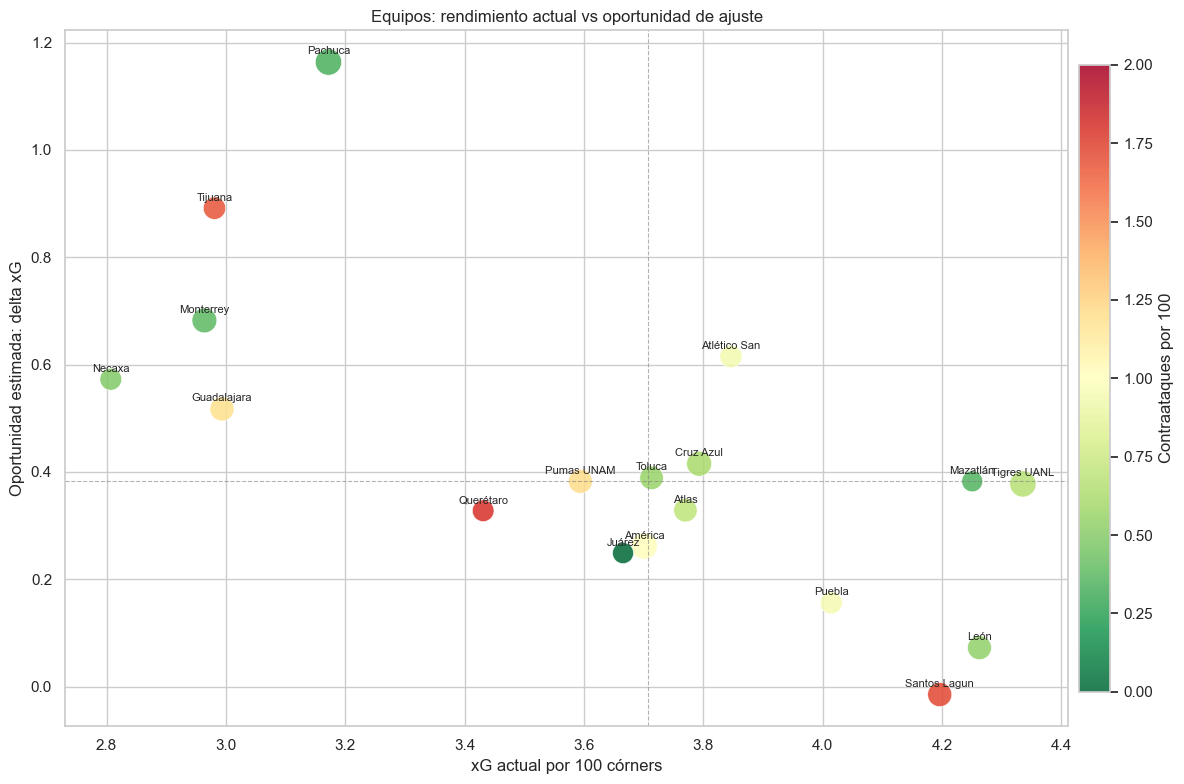

In [8]:
# Matriz de lectura rápida: calidad actual vs oportunidad de mejora.
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    team_recommendations['xg_per_100'], team_recommendations['delta_xg'],
    s=team_recommendations['n'] / 2.5,
    c=team_recommendations['counter_per_100'], cmap='RdYlGn_r',
    vmin=0, vmax=2, alpha=0.85, edgecolor='white', lw=0.5,
)
for _, row in team_recommendations.iterrows():
    ax.annotate(row['team'][:12], (row['xg_per_100'], row['delta_xg']), fontsize=8,
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
ax.axvline(team_recommendations['xg_per_100'].median(), color='gray', ls='--', lw=0.8, alpha=0.6)
ax.axhline(team_recommendations['delta_xg'].median(), color='gray', ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('xG actual por 100 córners')
ax.set_ylabel('Oportunidad estimada: delta xG')
ax.set_title('Equipos: rendimiento actual vs oportunidad de ajuste')
cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.03)
cbar.set_label('Contraataques por 100')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'recommendations_team_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Visualizaciones finales

Estas gráficas son para presentación: una vista de zonas recomendadas en cancha y una visual interactiva por equipo. La cancha resume dónde conviene orientar el entrenamiento; el plotly permite explorar perfiles de equipos.


,end_zone,n,obv_mean,xg_per_100,shot_rate,counter_per_100,retained_rate
0,central_box,7296,0.0160,4.0599,0.4345,0.8772,0.2288
3,six_yard,1830,0.0128,3.7568,0.2721,0.6011,0.2574
4,wide_box,1000,0.0118,3.0867,0.4540,0.5000,0.1910
1,edge_or_short,2602,-0.0123,2.7181,0.3125,0.9992,0.2479
2,recycled,292,-0.0159,2.5497,0.3116,1.0274,0.1952


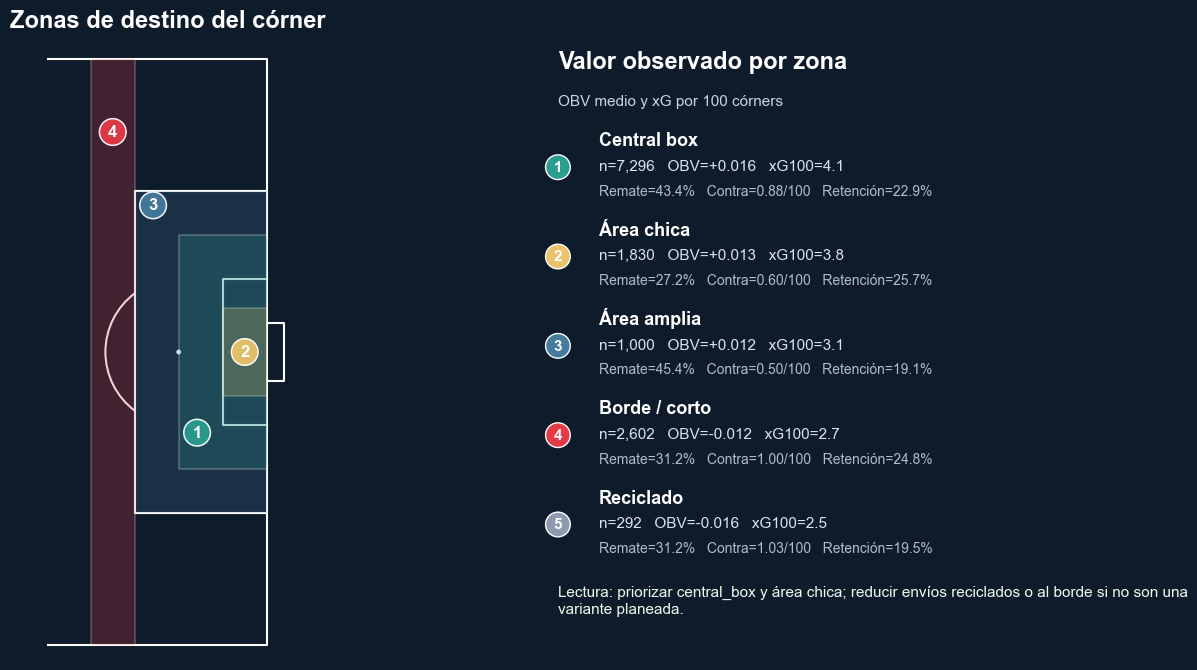

In [9]:
zone_stats = summarize(corners.groupby('end_zone', observed=True)).reset_index()
zone_order = ['central_box', 'six_yard', 'wide_box', 'edge_or_short', 'recycled']
zone_stats['end_zone'] = pd.Categorical(zone_stats['end_zone'], categories=zone_order, ordered=True)
zone_stats = zone_stats.sort_values('end_zone')
display(zone_stats.round(4))

# Mapa limpio de zonas: la cancha solo muestra áreas numeradas; la explicación va en una tabla lateral.
# Así evitamos encimar texto dentro del área chica y mantenemos lectura rápida para presentación.
zone_meta = {
    'central_box': ('1', 'Central box', '#2a9d8f'),
    'six_yard': ('2', 'Área chica', '#e9c46a'),
    'wide_box': ('3', 'Área amplia', '#457b9d'),
    'edge_or_short': ('4', 'Borde / corto', '#e63946'),
    'recycled': ('5', 'Reciclado', '#8d99ae'),
}

fig = plt.figure(figsize=(16, 8), facecolor=BG)
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.08)
ax = fig.add_subplot(gs[0, 0])
ax_info = fig.add_subplot(gs[0, 1])

pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff66', linewidth=1.5, goal_type='box')
pitch.draw(ax=ax)

# Rectángulos aproximados de zonas tácticas; dibujamos primero las zonas grandes y luego las pequeñas.
zones = [
    ('edge_or_short', 96, 0, 6, 80, (99, 70)),
    ('wide_box', 102, 18, 18, 44, (104.5, 60)),
    ('central_box', 108, 24, 12, 32, (110.5, 29)),
    ('six_yard', 114, 34, 6, 12, (117, 40)),
]
for name, x0, y0, width, height, marker_xy in zones:
    number, _, color = zone_meta[name]
    ax.add_patch(plt.Rectangle((x0, y0), width, height, color=color, alpha=0.24, ec='white', lw=1.2))
    ax.text(marker_xy[0], marker_xy[1], number, ha='center', va='center', color='white',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='circle,pad=0.35', fc=color, ec='white', lw=1.1, alpha=0.95))

ax.set_xlim(90, 123)
ax.set_ylim(-2, 82)
ax.set_title('Zonas de destino del córner', color='white', fontsize=17, fontweight='bold', pad=12)
ax.set_facecolor(BG)

ax_info.axis('off')
ax_info.set_facecolor(BG)
ax_info.text(0.0, 0.96, 'Valor observado por zona', color='white', fontsize=17, fontweight='bold', transform=ax_info.transAxes)
ax_info.text(0.0, 0.90, 'OBV medio y xG por 100 córners', color='#c9d4df', fontsize=11, transform=ax_info.transAxes)

y0 = 0.80
row_gap = 0.145
for i, zone in enumerate(zone_order):
    row = zone_stats[zone_stats['end_zone'].astype(str).eq(zone)]
    if row.empty:
        continue
    row = row.iloc[0]
    number, label, color = zone_meta[zone]
    y_pos = y0 - i * row_gap
    ax_info.text(0.00, y_pos, number, ha='center', va='center', color='white', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='circle,pad=0.35', fc=color, ec='white', lw=1.0), transform=ax_info.transAxes)
    ax_info.text(0.08, y_pos + 0.035, label, color='white', fontsize=13, fontweight='bold', transform=ax_info.transAxes)
    ax_info.text(0.08, y_pos - 0.005,
                 f'n={int(row.n):,}   OBV={row.obv_mean:+.3f}   xG100={row.xg_per_100:.1f}',
                 color='#d7e3ee', fontsize=11, transform=ax_info.transAxes)
    ax_info.text(0.08, y_pos - 0.045,
                 f'Remate={row.shot_rate*100:.1f}%   Contra={row.counter_per_100:.2f}/100   Retención={row.retained_rate*100:.1f}%',
                 color='#aebdcc', fontsize=10, transform=ax_info.transAxes)

ax_info.text(0.0, 0.08,
             'Lectura: priorizar central_box y área chica; reducir envíos reciclados o al borde si no son una variante planeada.',
             color='#f1faee', fontsize=11, wrap=True, transform=ax_info.transAxes)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'recommendations_zone_map.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


In [10]:
# Visual interactiva: cada punto es un equipo. Útil para explorar tradeoffs en el entregable HTML.
# La leyenda va abajo y horizontal para que no compacte el área de la gráfica.
fig = px.scatter(
    team_recommendations,
    x='shot_rate', y='xg_per_100', size='n', color='recommendation',
    hover_name='team',
    hover_data=['obv_mean', 'counter_per_100', 'short_pct', 'central_pct', 'delta_xg'],
    labels={
        'shot_rate': 'Tasa de remate',
        'xg_per_100': 'xG por 100 córners',
        'n': 'Volumen',
        'recommendation': 'Foco recomendado',
    },
    title='Perfil táctico por equipo: volumen, peligro y foco recomendado',
)
fig.update_traces(marker=dict(opacity=0.86, line=dict(width=1.2, color='white')))
fig.update_layout(
    width=1250,
    height=760,
    margin=dict(l=90, r=35, t=90, b=165),
    title=dict(x=0.5, y=0.98, font=dict(size=27)),
    legend=dict(
        title='Foco recomendado',
        orientation='h',
        yanchor='top', y=-0.15,
        xanchor='center', x=0.5,
        font=dict(size=14),
        title_font=dict(size=15),
    ),
    xaxis=dict(tickformat='.0%', title_standoff=18),
    yaxis=dict(title_standoff=18),
)
fig.show()


## 6 · Recomendación final para el cuerpo técnico

1. **No perseguir sólo más remates.** Outswinging produce más disparos, pero Inswinging compite en xG y OBV cuando ataca zonas interiores.
2. **Entrenar la zona antes que la etiqueta.** La evidencia de 03 y 04 apunta a `central_box` y zonas cercanas al área chica como el foco más robusto.
3. **Usar Short como variante.** Aporta retención y puede desordenar, pero los patrones cortos de bajo valor no deben ser la base ofensiva.
4. **Proteger sin sobrerreaccionar.** El contraataque desde córner es raro; el riesgo importa, pero no domina la decisión.
5. **Entrenar segunda fase.** Los remates indirectos y de segunda jugada tienen xG medio mayor que los directos; el rebote debe ser parte explícita del plan.
6. **Usar el modelo como ranking.** El modelo de OBV ayuda a priorizar patrones y equipos con oportunidad de mejora, no a predecir exactamente cada córner.

**Mensaje final:** el mejor plan no es cambiar todo el mix a un solo tipo; es reducir envíos de bajo valor, aumentar ataques a zonas centrales y entrenar la segunda jugada.
